Entrenando SVM con Kernel Lineal con 44391 mensajes...
Nota: Con 55k filas, esto puede tardar entre 30 y 60 segundos en tu RTX 5050.

REPORTE DE CLASIFICACIÓN - SVM (Unidad 3)
Tiempo de entrenamiento: 789.51 segundos
              precision    recall  f1-score   support

      Neutro       0.96      0.97      0.97      5577
      Tóxico       0.97      0.96      0.97      5521

    accuracy                           0.97     11098
   macro avg       0.97      0.97      0.97     11098
weighted avg       0.97      0.97      0.97     11098



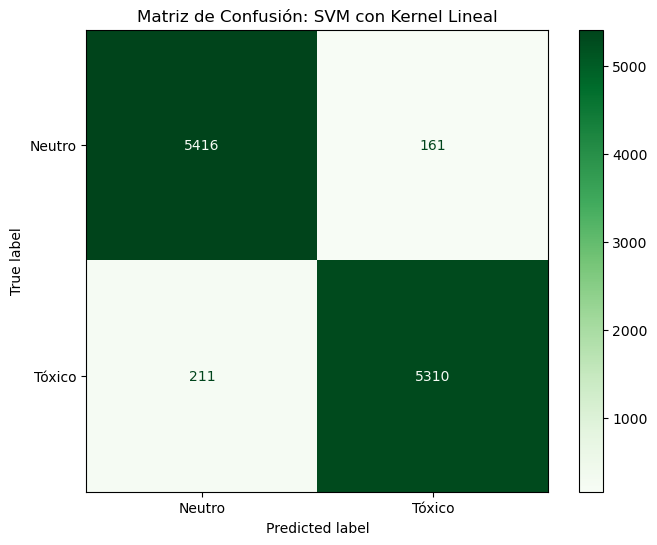


Mensaje: 'eres un bocachancla'
Predicción SVM: NEUTRO (Probabilidad de toxicidad: 0.2500)

Mensaje: 'muchas gracias por la ayuda'
Predicción SVM: NEUTRO (Probabilidad de toxicidad: 0.0043)

Mensaje: 'vete a freir esparragos zopenco'
Predicción SVM: TÓXICO (Probabilidad de toxicidad: 0.7199)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. CARGA DE DATOS
df = pd.read_csv('DATASET_LIMPIO_PARA_MODELOS.csv')
df = df.dropna(subset=['texto_limpio'])

X = df['texto_limpio']
y = df['toxicidad']

# 2. REPRESENTACIÓN DE DATOS: TF-IDF (Unidad 1)
# Usamos los mismos parámetros que en NB para que la comparativa sea justa
vectorizador = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tfidf = vectorizador.fit_transform(X)

# 3. DIVISIÓN DEL DATASET (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 4. MODELO: Support Vector Machine (Unidad 3)
# kernel='linear' es el más recomendado para texto de alta dimensionalidad.
# probability=True permite obtener el porcentaje de toxicidad (útil para el backend).
print(f"Entrenando SVM con Kernel Lineal con {X_train.shape[0]} mensajes...")
print("Nota: Con 55k filas, esto puede tardar entre 30 y 60 segundos en tu RTX 5050.")

inicio = time.time()
modelo_svm = SVC(kernel='linear', probability=True, random_state=42)
modelo_svm.fit(X_train, y_train)
fin = time.time()

# 5. EVALUACIÓN (Unidad 1)
y_pred = modelo_svm.predict(X_test)

print("\n" + "="*40)
print("REPORTE DE CLASIFICACIÓN - SVM (Unidad 3)")
print("="*40)
print(f"Tiempo de entrenamiento: {fin - inicio:.2f} segundos")
print(classification_report(y_test, y_pred, target_names=['Neutro', 'Tóxico']))

# 6. VISUALIZACIÓN: MATRIZ DE CONFUSIÓN (Unidad 1)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutro', 'Tóxico'])
disp.plot(cmap=plt.cm.Greens, ax=ax) # Usamos verde para diferenciarlo del azul de Bayes
plt.title('Matriz de Confusión: SVM con Kernel Lineal')
plt.savefig('matriz_confusion_svm.png')
plt.show()

# 7. PRUEBA ESPECÍFICA (Caso "Bocachancla")
def test_mensaje_svm(msg):
    # Aplicar la misma transformación que al entrenamiento
    msg_vec = vectorizador.transform([msg])
    pred = modelo_svm.predict(msg_vec)
    prob = modelo_svm.predict_proba(msg_vec)
    clase = "TÓXICO" if pred[0] == 1 else "NEUTRO"
    print(f"\nMensaje: '{msg}'")
    print(f"Predicción SVM: {clase} (Probabilidad de toxicidad: {prob[0][1]:.4f})")

test_mensaje_svm("eres un bocachancla")
test_mensaje_svm("muchas gracias por la ayuda")
test_mensaje_svm("vete a freir esparragos zopenco")

In [9]:
test_mensaje_svm(" voy  lascookies del  navegador   ")

NameError: name 'test_mensaje_svm' is not defined